# Face Image Analysis

## References
- [FLD-G]  Face landmark detection guide for Python. _Google AI Edge_. https://developers.google.com/edge/mediapipe/solutions/vision/face_landmarker/python
- [FLD-NB] Face Landmarks Detection with MediaPipe Tasks. https://github.com/google-ai-edge/mediapipe-samples/blob/main/examples/face_landmarker/python/%5BMediaPipe_Python_Tasks%5D_Face_Landmarker.ipynb

## Imports and visualization utilities

To be run once when initializing. Copied from [FLD-NB].

In [1]:
import os
import sys
import warnings

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles

import numpy as np

import matplotlib.pyplot as plt

import cv2


def draw_landmarks_on_image(image_rgb, detection_result):
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    face_landmarks_list = detection_result.face_landmarks
    annotated_image = np.copy(image_bgr)

    # Loop through the detected faces to visualize.
    for idx in range(len(face_landmarks_list)):
        face_landmarks = face_landmarks_list[idx]

    # Draw the face landmarks.


    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_TESSELATION,
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_tesselation_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_CONTOURS,
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_contours_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_IRIS,
          landmark_drawing_spec=None,
          connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_IRIS,
          landmark_drawing_spec=None,
          connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())

    annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR)
    return annotated_image

def plot_face_blendshapes_symbar_graph(blendshapes):
    # Extract the face blendshapes category names and scores.
    blendshapes_names = [blendshapes_category.category_name for blendshapes_category in blendshapes]
    blendshapes_scores = [blendshapes_category.score for blendshapes_category in blendshapes]
    # The blendshapes are ordered in decreasing score value.
    blendshapes_ranks = range(len(blendshapes_names))

    fig, ax = plt.subplots(figsize=(12, 12))
    bar = ax.barh(blendshapes_ranks, blendshapes_scores, label=[str(x) for x in blendshapes_ranks])
    ax.set_yticks(blendshapes_ranks, blendshapes_names)
    ax.invert_yaxis()

    # Label each bar with values
    for score, patch in zip(blendshapes_scores, bar.patches):
        ax.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{score:.4f}", va="top")

    ax.set_xlabel('Score')
    ax.set_title("Face Blendshapes")
    plt.tight_layout()

def imshow(image, ax=None, title=None):
    if return_ax := (ax is None):
        fig, ax = plt.subplots()
    ax.imshow(image)
    ax.axis('off')
    if title:
        ax.set_title(title)
    if return_ax:
        return ax

## Creating the MediaPipe task

To be run once!

This is very long because it loads heavy ML models in memory and initializes the underlying C++ MediaPipe graph framework.

In [2]:
model_path = "models/face_landmarker_v2_with_blendshapes.task"

try:
    model_size = os.path.getsize(model_path)
    print("Model found:", model_path)
except FileNotFoundError:
    print("Model not found:", model_path)
    print("Downloading model...")

    import subprocess
    subprocess.run(["wget", "-O", model_path, "-q", "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"], check=True)
    model_size = os.path.getsize(model_path)
    print("Model downloaded")
finally:
    print(f"Size: {model_size / (2 ** 20):.3g} MB")

Model found: models/face_landmarker_v2_with_blendshapes.task
Size: 3.58 MB


In [3]:
base_options = python.BaseOptions(
    model_asset_path=model_path,
    delegate=python.BaseOptions.Delegate.CPU  # Use GPU if you have a compatible GPU and want faster inference
)

options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True,
    num_faces=1)

In [4]:
if sys.version_info >= (3, 13):
    warnings.warn("MediaPipe’s official wheels can occasionally experience native deadlocks on Python 3.13+ due to changes in the C-API and GIL threading behavior. Please use Python 3.12 or lower.")

if tuple(map(int, mp.__version__.split('.'))) > (0, 10, 35):
    warnings.warn("MediaPipe version bigger than 0.10.35 may cause silent failure of create_from_options(). Please use MediaPipe version 0.10.35 or lower.")

detector = vision.FaceLandmarker.create_from_options(options)

I0000 00:00:1787845494.064329 40327671 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 11, prefix = pthread-default
W0000 00:00:1787845494.064600 40327671 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1787845494.101863 40327671 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1787845494.102799 40327675 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787845494.107772 40327682 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## Analyzing your image

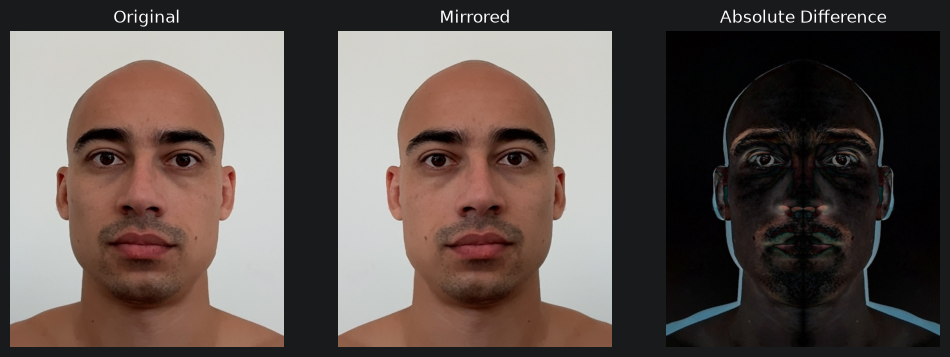

In [5]:
# Load image

image_path = "data/alexandre-charvier.jpg"
mp_image = mp.Image.create_from_file(image_path)

# Show loaded image
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
egami_rgb = cv2.flip(image_rgb, 1)
mirror_diff = cv2.absdiff(image_rgb, egami_rgb)

fig, axs = plt.subplots(1, 3, figsize=(12, 12))
imshow(image_rgb, ax=axs[0], title="Original")
imshow(egami_rgb, ax=axs[1], title="Mirrored")
imshow(mirror_diff, ax=(ax := axs[2]), title="Absolute Difference")
plt.show()

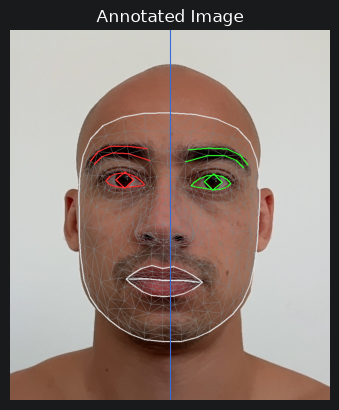

In [6]:
# Detect face landmarks from the input image
detection_result = detector.detect(mp_image)

# Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(mp_image.numpy_view(), detection_result)
ax = imshow(annotated_image, title="Annotated Image")
ax.axvline(annotated_image.shape[1] // 2, lw=0.8)
plt.show()

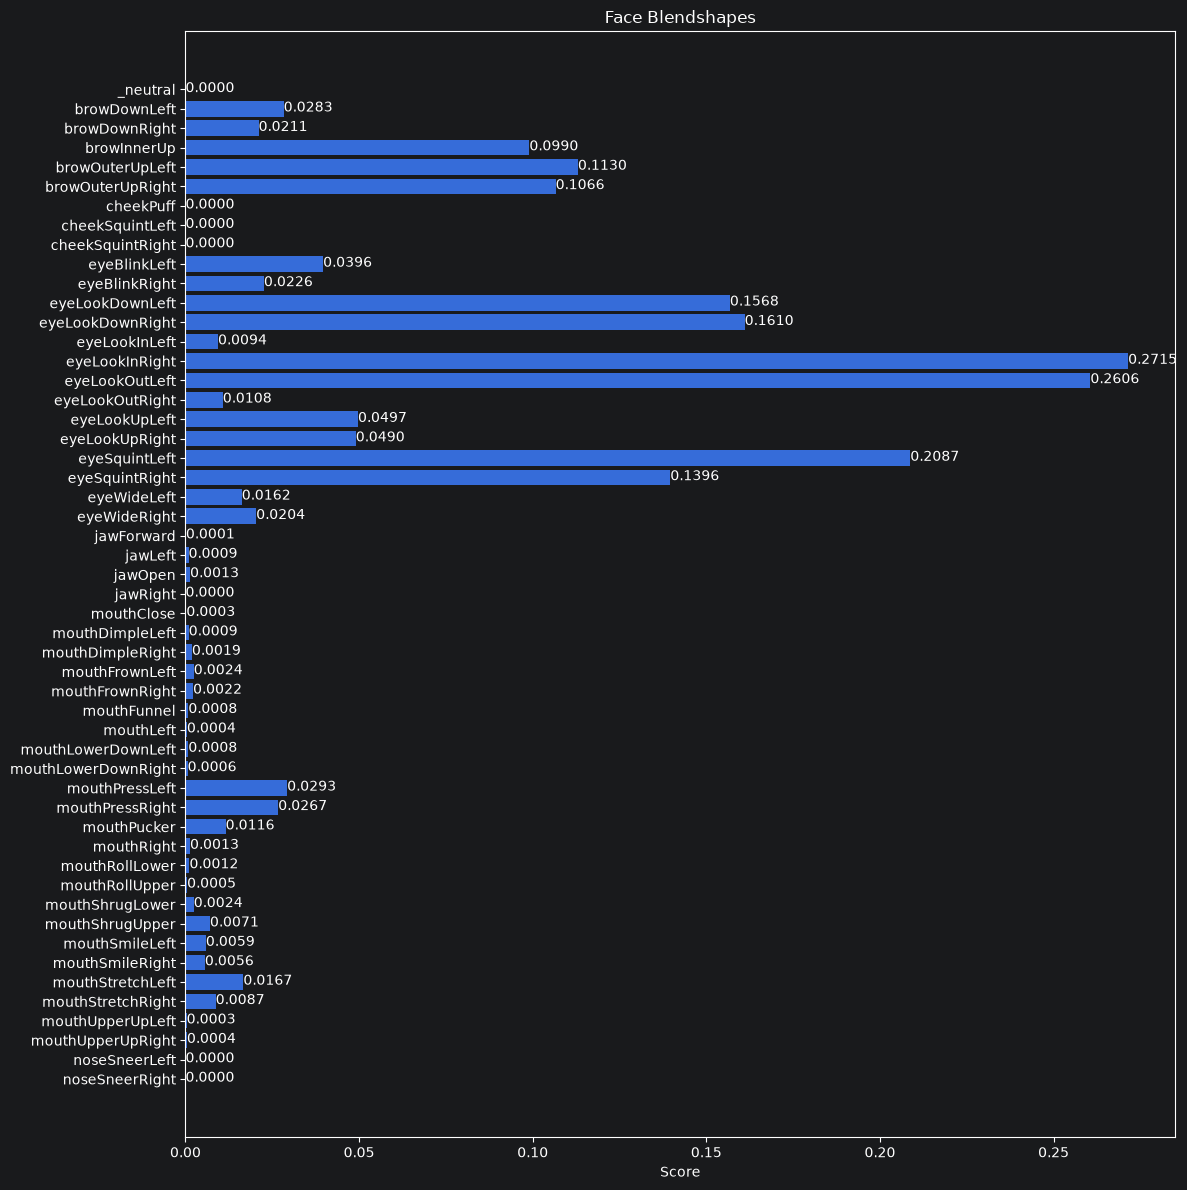

In [7]:
blendshapes = detection_result.face_blendshapes[0]
plot_face_blendshapes_symbar_graph(blendshapes)
plt.show()

In [8]:
print(detection_result.facial_transformation_matrixes)

[array([[  0.9988674 ,   0.02915908,  -0.03760503,  -0.12927984],
       [ -0.027839  ,   0.99899423,   0.03516217,  -0.5460152 ],
       [  0.03859249,  -0.03407543,   0.9986742 , -24.948273  ],
       [  0.        ,   0.        ,   0.        ,   1.        ]],
      dtype=float32)]
